# DEA WIT Change Detection Module <img align="right" src="./dea_logo.jpg"/>


* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_s2am_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2am_ard_3), 
[ga_s2bm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2bm_ard_3),
[ga_s2cm_ard_3](https://explorer.dea.ga.gov.au/products/ga_s2cm_ard_3),
[ga_ls5t_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls5t_ard_3),
[ga_ls7e_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls7e_ard_3),
[ga_ls8c_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls8c_ard_3)
* **Special requirements:** An _optional_ description of any special requirements, e.g. If running on the [NCI](https://nci.org.au/), ensure that `module load otps` is run prior to launching this notebook
* **Prerequisites:** An _optional_ list of any notebooks that should be run or content that should be understood prior to launching this notebook

## Background
Wetlands provide a wide range of ecosystem services including improving water quality, carbon sequestration, as well as providing habitat for fish, amphibians, reptiles and birds.  Managing wetlands in Australia is challenging due to competing pressures for water availability and highly variable climatic settings. The DEA WIT Change Detection tool is a module for the Wetland Insight Tool (WIT), which assists in the detection and analysis of changes in wetlands and water bodies across Australia. This tool was developed to support the National Wetland Inventory Project, a collaborative effort between Geoscience Australia, states and territories and the Department of Climate Change, Energy, Environment and Water (DCCEEW). By contributing to the National Wetlands Inventory, this work can help build a vital reporting tool for monitoring the health and condition of Australia’s wetlands, supporting managers and authorities at local, state, and federal levels.

## Ginini Case Study
The Ginini Flats Wetland Complex was designated as a Ramsar site in 1996. It is located near Mount Ginini within Namadgi National Park, approximately 40 km south-west of Canberra in the Australian Capital Territory. The complex sits within the upper reaches of the Cotter River catchment, which forms part of Australia’s largest river system, the Murray–Darling Drainage Division (Bureau of Meteorology, 2009). The regional climate is classified as sub-alpine, with average temperatures ranging from a minimum of 2.0 °C to a maximum of 21.0 °C, and snowfall occurring in the colder months.

In 2003, extensive bushfires burned through the Ginini area and parts of Canberra, significantly affecting the wetland and its surrounding landscape. Following the fires, the region entered a period of drought. WIT classifications from this time showed a near-persistent shift in water-related signatures within the wetland, indicating that the site was suitable for change-detection analysis.

Information for this case study is drawn from the Ginini Flats Wetland Complex Ramsar Site Management Plan (2017).

# Workflow
![workflow](workflowCD.png)


## Related Products

* [DEA Wetlands Insight Tool (Ramsar Wetlands)](https://knowledge.dea.ga.gov.au/data/product/dea-wetlands-insight-tool-ramsar-wetlands/)
* [DEA Fractional Cover](https://knowledge.dea.ga.gov.au/data/product/dea-fractional-cover-landsat/)
* [DEA Tasseled Cap Indices Percentiles Calendar Year (Landsat)](https://knowledge.dea.ga.gov.au/data/product/dea-tasseled-cap-percentiles-landsat/)
* [DEA Water Observations (Landsat)](https://knowledge.dea.ga.gov.au/data/product/dea-water-observations-landsat/)
* [DEA Maps](https://maps.dea.ga.gov.au/)
***

# Getting Started

### Install Software

In [4]:
!pip install pymannkendall
!pip install matplotlib-scalebar

  Using cached pymannkendall-1.4.3-py3-none-any.whl.metadata (14 kB)
Using cached pymannkendall-1.4.3-py3-none-any.whl (12 kB)
  Using cached matplotlib_scalebar-0.9.0-py3-none-any.whl.metadata (18 kB)
Using cached matplotlib_scalebar-0.9.0-py3-none-any.whl (16 kB)


### Load Packages
Import Python packages that are used for the analysis.


In [9]:
import datacube
import sys
import dea_tools
sys.path.insert(1, '../Tools/')
#from dea_tools.app import wetlandsinsighttool
from dea_tools.plotting import display_map, rgb
#from dea_tools.wetlands import WIT_drill, spatial_wit
import os
import re
import itertools
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import datetime
import glob
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
import matplotlib.patches as mpatches
from statsmodels.tsa.seasonal import seasonal_decompose
from datacube.utils.geometry import Geometry, CRS
from matplotlib.colors import Normalize
from matplotlib_scalebar.scalebar import ScaleBar
from datacube import Datacube
import datacube
import dea_tools.datahandling
import dea_tools.bandindices
from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)
import importlib.util

# Add Tools directory to path first
tools_path = os.path.abspath('../Tools/')
if tools_path not in sys.path:
    sys.path.insert(0, tools_path)

# Load the local wetlands module
wetlands_file = os.path.join(tools_path, 'dea_tools', 'wetlands.py')

if os.path.exists(wetlands_file):
    print("Found local wetlands.py")
    try:
        # Load the module
        spec = importlib.util.spec_from_file_location("dea_tools.wetlands", wetlands_file)
        if spec is None:
            print("❌ Could not create spec from file")
        else:
            wetlands_local = importlib.util.module_from_spec(spec)
            
            # Try to execute the module
            try:
                spec.loader.exec_module(wetlands_local)
                print("✅ Module loaded successfully")
                
                # Check for WIT_drill
                if hasattr(wetlands_local, 'WIT_drill'):
                    WIT_drill = wetlands_local.WIT_drill
                    print("✅ Successfully imported WIT_drill")
                else:
                    print("❌ WIT_drill not found after loading")
                    print(f"Available attributes: {[x for x in dir(wetlands_local) if not x.startswith('_')][:20]}")
            except Exception as load_error:
                print(f"❌ Error executing module: {load_error}")
                import traceback
                traceback.print_exc()
                
    except Exception as e:
        print(f"❌ Error loading module: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"❌ Local wetlands.py not found at: {wetlands_file}")
    print(f"Current directory: {os.getcwd()}")
    print(f"Tools path: {tools_path}")

if os.path.exists(wetlands_file):
    print("Found local wetlands.py")
    try:
        # Load the module
        spec = importlib.util.spec_from_file_location("dea_tools.wetlands", wetlands_file)
        if spec is None:
            print("❌ Could not create spec from file")
        else:
            wetlands_local = importlib.util.module_from_spec(spec)
            
            # Try to execute the module
            try:
                spec.loader.exec_module(wetlands_local)
                print("✅ Module loaded successfully")
                
                # Check for spatial_wit
                if hasattr(wetlands_local, 'spatial_wit'):
                    spatial_wit = wetlands_local.spatial_wit
                    print("✅ Successfully imported spatial_wit")
                else:
                    print("❌ spatial_wit not found after loading")
                    print(f"Available attributes: {[x for x in dir(wetlands_local) if not x.startswith('_')][:20]}")
            except Exception as load_error:
                print(f"❌ Error executing module: {load_error}")
                import traceback
                traceback.print_exc()
                
    except Exception as e:
        print(f"❌ Error loading module: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"❌ Local wetlands.py not found at: {wetlands_file}")
    print(f"Current directory: {os.getcwd()}")
    print(f"Tools path: {tools_path}")
    
# Add Tools directory to path first
tools_path = os.path.abspath('../Tools/')
if tools_path not in sys.path:
    sys.path.insert(0, tools_path)


Found local wetlands.py


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/8787/status,
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38029,Workers: 1
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:36657,Total threads: 2
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/41101/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:36137,


✅ Module loaded successfully
✅ Successfully imported WIT_drill
Found local wetlands.py


/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39553 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/39553/status,
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/39553/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35053,Workers: 1
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/39553/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:38999,Total threads: 2
Dashboard: /user/cassandra.newman@ga.gov.au/proxy/35303/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:40321,


✅ Module loaded successfully
✅ Successfully imported spatial_wit


2025-11-27 22:15:21,382 - distributed.scheduler - WARNING - Detected different `run_spec` for key 'dataset-e8dc32af362b44b68c73bc9f20f07225' between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: (<function execute_task at 0x7f39066a8670>, (Dataset <id=e8dc32af-362b-44b6-8c73-bc9f20f07225 product=ga_ls7e_ard_3 location=s3://dea-public-data/baseline/ga_ls7e_ard_3/091/085/2002/12/15/ga_ls7e_ard_3-0-0_091085_2002-12-15_final.stac-item.json>,), {})
new run_spec: (<function execute_task at 0x7f39066a8670>, (Dataset <id=e8dc32af-362b-44b6-8c73-bc9f20f07225 product=ga_ls7e_ard_3 location=s3://dea-public-data/baseline/ga_ls7e_ard_3/091/08

# Parameters to Change
This code block defines the parameters used as inputs for the tool. The `csv_path` refers to the output generated by the Wetland Insight Tool (WIT), while `component` specifies the classification category selected for change-detection analysis. The `polygon_path` should match the spatial input originally used in the WIT so that the extracted change-point imagery aligns with the same area for validation.

Changing the `component` in the code produces different sets of change points in the resulting graphs. When analysing a site in detail, it is recommended to explore each component and examine how it varies over the selected time period. In this case study, the NPV (no photosynthetic vegetation) component most clearly captured the impacts of the 2003 bushfires.

In [10]:
csv_path = "178.csv"              # ACTION: Add CSV output from WIT tool (This is from DEA Maps. WIT tool output does not capitalise column names, so adjust if needed).
component = "NPV"                 # ACTION: Change this to the component you want to analyze (e.g. "PV", "GV", "NPV", "WET", "WATER").
polygon_path = "ginini_flats.shp" # ACTION: Change this if your polygon file has another name.

# Create output folder for validation images
out_folder = "validation_images"
os.makedirs(out_folder, exist_ok=True)

## Connect to the Datacube
Connect to the datacube so we can access DEA data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [11]:
dc = Datacube(app="change_detection_validation")
df = pd.read_csv(csv_path)
df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

## Prepare Data 

This code chunk edits out low quality data and smooths it to improve readability and reduce noise.   

In [12]:
def generate_low_quality_data_periods(df, min_gooddata=0.9, cloud_cover_col='cloud_cover'):
    """
    Mark periods with low-quality data:
    - Landsat 5-8 SLC-off gap (Nov 2011 - Apr 2013)
    - Low observation density (less than 4 observations in 365 days)
    - Low quality data based on cloud cover (if cloud_cover_col exists)
    """
    df = df.copy()
    df["off_value"] = 0
    
    # Landsat 5-8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100
    
    # Low observation density (less than 4 in 365 days)
    df_sorted = df.sort_values('TIME').reset_index(drop=True)
    for i in range(len(df_sorted) - 3):
        if (df_sorted.loc[i + 3, "TIME"] - df_sorted.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df_sorted.loc[i, "TIME"])
                & (df["TIME"] <= df_sorted.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    
    return df

df = generate_low_quality_data_periods(df)  

if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

# Create low quality ranges - groups low quality consecutive periods and records the start and end dates

low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Smooth data

pv = df.set_index("TIME")[component].astype(float)
pv = pv.resample('MS').mean().interpolate(method='cubic')  # Smooth monthly data using MS and interpolate the missing months with cubic interpolation

# Time Series Decomposition and Change Detection
This code removes large temporal gaps larger than 60 days (~2 months) and decomposes the time series into trend, seasonal and residual data using an additive model over a 12 month period. It also detects abrupt changes when statistics beyond the below number of standard deviations is flagged as an abrupt change.

In [13]:
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    result = seasonal_decompose(pv_filtered, model="additive", period=12)
    trend = result.trend
    seasonal = result.seasonal
    resid = result.resid

threshold = 2 * resid.std()                                  #ACTION: Adjust threshold for more sensitive change detection (2 is the default as it follows the 2-sigma rule)
change_points = resid[abs(resid) > threshold].index
change_points_sorted = sorted(change_points)

 # PLOT: Time Series Decomposition

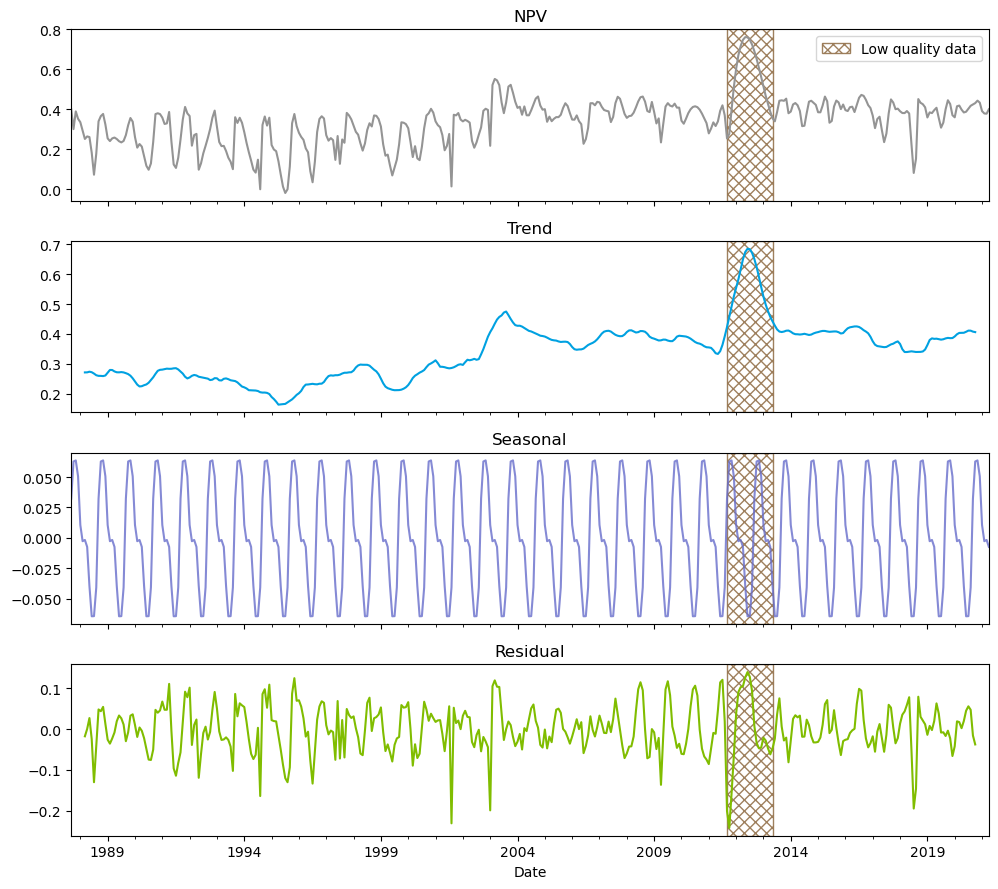

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

pv.plot(ax=axes[0], title=f"{component}", color="#949494")
trend.plot(ax=axes[1], title="Trend", color="#00A1E1")
seasonal.plot(ax=axes[2], title="Seasonal", color="#676dcb", alpha = 0.8) #676dcb #F8B22C
resid.plot(ax=axes[3], title="Residual", color="#80BD00")

    # Shade low-quality data
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="#94724C", 
                    hatch="xxx", alpha=0.9)

# Add legend for low-quality data 
low_quality_patch = mpatches.Patch(
    facecolor="none", edgecolor="#94724C", hatch="xxx", label="Low quality data", alpha=0.9
)

# Add the legend to just the top plot (or whichever you want)
axes[0].legend(handles=[low_quality_patch], loc="upper right", frameon=True)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

### *What is happening in the graph?*
Firstly, the brown hatching over the low-data region reflects known sensor issues with Landsat 7. The steep curve under the hatching appears due to smoothing, but this data is not actually incorporated into the analysis.

The NVP data are then decomposed, beginning with the trend component. During the first half of the time series, the trend remains low, followed by a sharp increase where the classification value rises by approximately 25% and stays elevated for the remainder of the period. The seasonal component isolates any cyclical patterns that correspond to temperature changes or seasonal variability. Finally, the residual component captures any variation that cannot be explained by either the trend or the seasonal patterns.

The gradual and abrupt changes will be statistically extracted in the following code.

# Gradual Change
Gradual change is assessed using Theil–Sen regression with Mann–Kendall significance. The slope and p-value indicate whether a component is experiencing a positive or negative trend and how statistically significant that trend is. This approach is robust to outliers, making it well-suited for detecting long-term environmental change. To reliably identify gradual trends and avoid false positives, the code requires at least four years of data or a minimum of 50 observations.

NPV is increasing at 0.0055 per year on average (p-value: 0.0000)


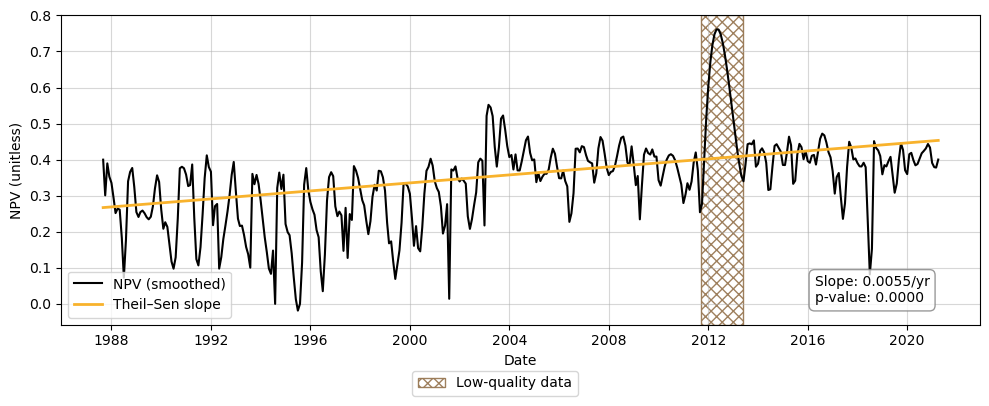

In [15]:
def mk_with_slopes(y, alpha=0.05):
    """
    Mann-Kendall test (Mann 1945, Kendall 1975, Gilbert 1987)
    Returns p-value, slope, and intercept.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept'])

    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)

    return res(p, slope, intercept)

# Smooth component after analysis (cubic monthly interpolation)

df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

#Smooth component time series for plotting

smoothed = df.set_index("TIME")[component].resample("MS").mean().interpolate(method="cubic")

# Run Mann–Kendall and Theil–Sen slope
mk_result = mk_with_slopes(smoothed)
p = mk_result.p
slope = mk_result.slope
intercept = mk_result.intercept

# Calculate per-year slope (slope is per month, so multiply by 12)
slope_per_year = slope * 12

# Print trend comment before plotting
if slope > 0:
    print(f"{component} is increasing at {slope_per_year:.4f} per year on average (p-value: {p:.4f})")
elif slope < 0:
    print(f"{component} is decreasing at {abs(slope_per_year):.4f} per year on average (p-value: {p:.4f})")
else:
    print(f"{component} shows no trend (slope: {slope_per_year:.4f} per year, p-value: {p:.4f})")

# Prepare Theil–Sen regression line
x_num = date2num(smoothed.index)
y_line = np.arange(len(smoothed)) * slope + intercept

# Plot smoothed data + Theil–Sen line + low-quality shading
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Smoothed data
ax.plot(smoothed.index, smoothed, color="black", label=f"{component} (smoothed)")

# Theil–Sen slope line
ax.plot(smoothed.index, y_line, color="#F8B22C", linewidth=2, label="Theil–Sen slope")

# Shade low-quality data
low_quality_patch = mpatches.Patch(facecolor="none", edgecolor="#94724C", 
                                   hatch="xxx", label="Low-quality data", alpha=0.9)

for start, end in low_quality_ranges:
    ax.axvspan(start, end, facecolor="none", edgecolor="#94724C", hatch="xxx", alpha=0.9)

# Annotate slope and p-value
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Final layout and styling
ax.set_ylabel(f"{component} (unitless)")
ax.set_xlabel("Date")
ax.grid(alpha=0.5)

# Legend below plot
fig.legend(
    handles=[low_quality_patch],
    loc="lower center",
    ncol=1,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

ax.legend(loc='lower left', frameon=True)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

### *What is happening in the graph?*
The gradient, averaged across the full time period, shows a clear annual increase of 0.0055 (p = 0.000). This upward trend is driven by a sharp rise around 2003, after which values remain consistently elevated. Although several major dips occur which is outlined in the abrupt change detection section, the overall pattern becomes less variable following the 2003 spike.

# Abrupt Change
This code uses the decomposition plot and flags change when values exceed the 2-standard-deviation (2-sigma) threshold. While abrupt changes can reflect real environmental events such as wildfires, deforestation, or flooding, they can also reveal errors in the data that can then be investigated and corrected.

Low-quality range: 2011-09-11 to 2013-05-20

Before low-quality filtering: 14 change points
  - 1988-07-01
  - 1992-05-01
  - 1994-08-01
  - 1995-07-01
  - 1995-11-01
  - 1996-07-01
  - 2001-08-01
  - 2003-01-01
  - 2009-04-01
  - 2011-07-01
  - 2011-11-01
  - 2012-05-01
  - 2012-07-01
  - 2018-07-01
  REMOVED (low-quality): 2011-11-01
  REMOVED (low-quality): 2012-05-01
  REMOVED (low-quality): 2012-07-01

Final change points: 11
  1. 1988-07-01
  2. 1992-05-01
  3. 1994-08-01
  4. 1995-07-01
  5. 1995-11-01
  6. 1996-07-01
  7. 2001-08-01
  8. 2003-01-01
  9. 2009-04-01
  10. 2011-07-01
  11. 2018-07-01

Threshold: 0.1174 (2 × std = 0.0587)


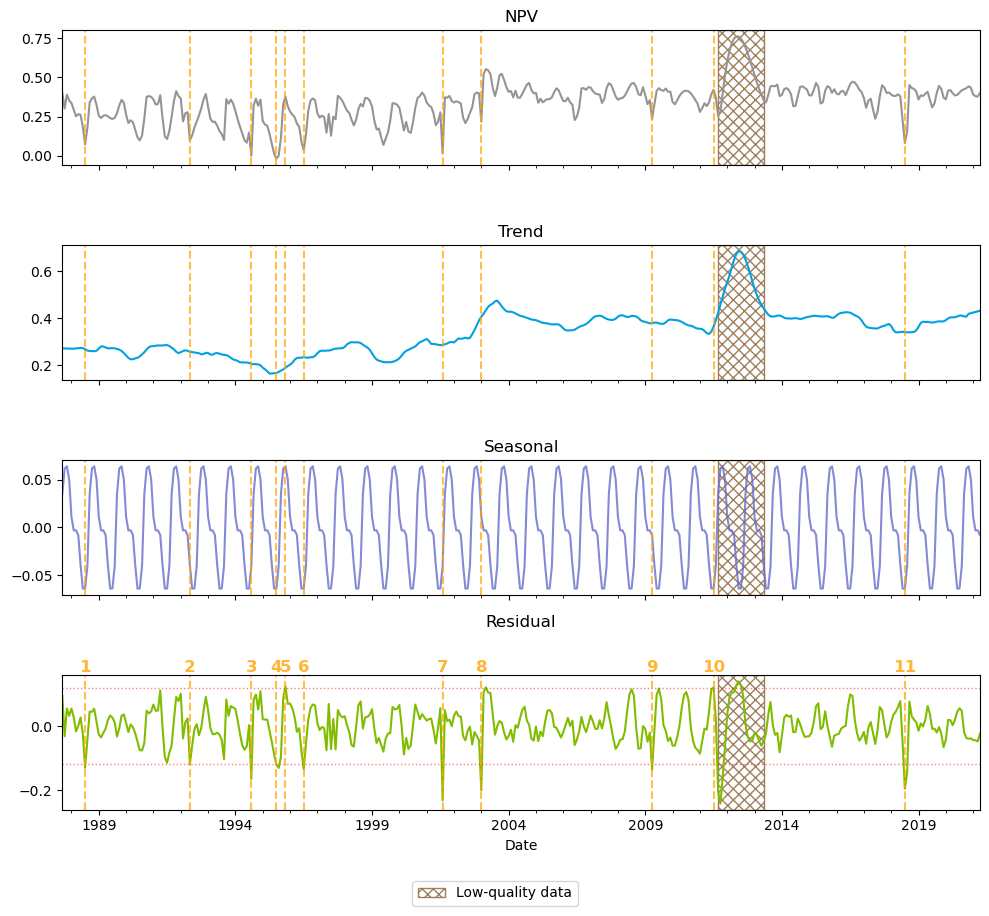

In [16]:
def generate_low_quality_data_periods(df):
  
    df = df.copy()
    df["off_value"] = 0
    
    # Landsat 5-8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100
    
    # Low observation density (less than 4 in 365 days)
    df_sorted = df.sort_values('TIME').reset_index(drop=True)
    for i in range(len(df_sorted) - 3):
        if (df_sorted.loc[i + 3, "TIME"] - df_sorted.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df_sorted.loc[i, "TIME"])
                & (df["TIME"] <= df_sorted.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

def is_in_low_quality_range_strict(date, low_quality_ranges):
    """
    Strictly check if a date falls within low-quality range, including boundaries.
    """
    for start, end in low_quality_ranges:
        # Check if date is within or very close to the range (within 1 month)
        buffer = pd.Timedelta(days=31)
        if (start - buffer) <= date <= (end + buffer):
            return True
    return False

def identify_steep_slope_regions(resid, threshold_multiplier=2.0, slope_window_months=3):

    resid_clean = resid.dropna()
    if len(resid_clean) < 12:
        return []
    
    threshold = threshold_multiplier * resid_clean.std()
    
    # Find all points exceeding threshold
    exceeds_threshold = abs(resid_clean) > threshold
    candidate_dates = resid_clean.index[exceeds_threshold].tolist()
    
    if len(candidate_dates) < 2:
        return candidate_dates
    
    # Group consecutive points that are close together (within slope_window_months)
    slope_regions = []
    current_region = [candidate_dates[0]]
    
    for i in range(1, len(candidate_dates)):
        days_diff = (candidate_dates[i] - candidate_dates[i-1]).days
        if days_diff < slope_window_months * 30:  # Within the window
            current_region.append(candidate_dates[i])
        else:
            # End of current region
            if len(current_region) >= 2:
                # This is a steep slope region - keep only start and end
                slope_regions.append((current_region[0], current_region[-1]))
            else:
                # Single point, not a slope - keep it as is
                slope_regions.append((current_region[0], current_region[0]))
            current_region = [candidate_dates[i]]
    
    # Handle last region
    if len(current_region) >= 2:
        slope_regions.append((current_region[0], current_region[-1]))
    else:
        slope_regions.append((current_region[0], current_region[0]))
    
    # Extract change points: start and end of each region, or single points
    change_points = []
    for start, end in slope_regions:
        if start == end:
            # Single point
            change_points.append(start)
        else:
            # Steep slope region - keep only start and end
            change_points.append(start)
            # Only add end if it's significantly separated from start (at least 2 months)
            if (end - start).days >= 60:
                change_points.append(end)
            # Otherwise just keep the start
    return sorted(set(change_points))

# Validate component exists
if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

# Ensure TIME is datetime type
if not pd.api.types.is_datetime64_any_dtype(df['TIME']):
    df['TIME'] = pd.to_datetime(df['TIME'])

# Mark low-quality data periods
df = generate_low_quality_data_periods(df)

# Create low quality ranges
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))
        print(f"Low-quality range: {start.date()} to {end.date()}")

# Prepare data
pv = df.set_index("TIME")[component].astype(float)

# Smooth data BEFORE decomposition
pv_smooth = pv.resample('MS').mean().interpolate(method='cubic')

# Filter large gaps (>60 days)
gaps = pv_smooth.index.to_series().diff().dt.days
pv_filtered = pv_smooth.loc[gaps.fillna(1) < 60]

# Check if we have enough data
if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    # Decompose time series using smoothed, filtered data
    result = seasonal_decompose(
        pv_filtered, 
        model="additive", 
        period=12,
        extrapolate_trend='freq'
    )
    
    trend = result.trend
    seasonal = result.seasonal
    resid = result.resid.dropna()
    
    # Identify steep slope regions (this handles clustering automatically)
    change_points_detected = identify_steep_slope_regions(
        resid, 
        threshold_multiplier=2.0,
        slope_window_months=4  # Points within 4 months are considered part of same slope
    )
    
    print(f"\nBefore low-quality filtering: {len(change_points_detected)} change points")
    for cp in change_points_detected:
        print(f"  - {cp.date()}")
    
    # STRICTLY filter out change points in low-quality ranges
    change_points_filtered = []
    for cp in change_points_detected:
        if not is_in_low_quality_range_strict(cp, low_quality_ranges):
            change_points_filtered.append(cp)
        else:
            print(f"  REMOVED (low-quality): {cp.date()}")
    
    change_points_sorted = sorted(change_points_filtered)
    
    print(f"\nFinal change points: {len(change_points_sorted)}")
    for idx, cp in enumerate(change_points_sorted, start=1):
        print(f"  {idx}. {cp.date()}")
    print(f"\nThreshold: {2.0 * resid.std():.4f} (2 × std = {resid.std():.4f})")
    
    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
    
    pv_filtered.plot(ax=axes[0], title=f"{component}", color="#949494")
    result.trend.plot(ax=axes[1], title="Trend", color="#00A1E1")
    result.seasonal.plot(ax=axes[2], title="Seasonal", color="#676dcb", alpha = 0.8)
    result.resid.plot(ax=axes[3], color="#80BD00")
    axes[3].set_title("Residual", pad=35)

    # Show threshold lines
    threshold_val = 2.0 * resid.std()
    axes[3].axhline(y=threshold_val, color='r', linestyle=':', alpha=0.5, linewidth=1, label='±2σ threshold')
    axes[3].axhline(y=-threshold_val, color='r', linestyle=':', alpha=0.5, linewidth=1)
    
    # Label axes
    axes[-1].set_xlabel("Date")
    
    # Shade low-quality data
    low_quality_patch = mpatches.Patch(facecolor="none", edgecolor="#94724C", 
                                       hatch="xxx", label="Low-quality data", alpha=0.9)
    
    for ax in axes:
        for start, end in low_quality_ranges:
            ax.axvspan(start, end, facecolor="none", edgecolor="#94724C", 
                       hatch="xxx", alpha=0.9)
    
    # Mark and label change points
    for idx, cp in enumerate(change_points_sorted, start=1):
        for ax in axes:
            ax.axvline(cp, color="orange", linestyle="--", alpha=0.7, linewidth=1.5)
        y_pos = result.resid.max() * 1.2 if result.resid.max() > 0 else result.resid.min() * 1.2
        axes[3].text(
            cp,
            y_pos,
            str(idx),
            color="orange", alpha = 0.8,
            fontsize=12,
            fontweight="bold",
            ha="center",
            rotation=0,
            clip_on=False,
        )
    
    # Legend
    fig.legend(
        handles=[low_quality_patch],
        loc="lower center",
        ncol=1,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02)
    )
    
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    

### *What is happening in the graph?*
The red dots on the residual plot mark the two-standard-deviation threshold, and any values exceeding this threshold are flagged and labelled from 1 to 11 with orange markers. These labels correspond to the timestamps listed in the table below.

## Create dataframe with change ID and date

In [17]:
change_data = pd.DataFrame({
    "Change_ID": range(1, len(change_points_sorted) + 1),
    "Timestamp": change_points_sorted
})
change_data_string = change_data.to_string(index=False)
change_data
print(change_data_string)

 Change_ID  Timestamp
         1 1988-07-01
         2 1992-05-01
         3 1994-08-01
         4 1995-07-01
         5 1995-11-01
         6 1996-07-01
         7 2001-08-01
         8 2003-01-01
         9 2009-04-01
        10 2011-07-01
        11 2018-07-01


# Validation imagery

Now it is time to validate the change-detection points that were automatically extracted based on the specified threshold. This step helps identify the causes of each detected change to support further investigation. Validation is carried out using RGB imagery (red, green, blue) alongside the spatial WIT classifications.

## Pull polygon of area of interest 

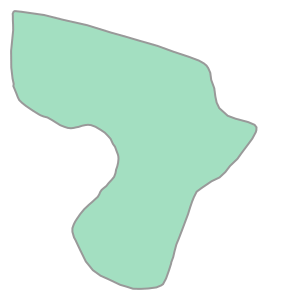

In [18]:
ginini = gpd.read_file(polygon_path)
ginini = Geometry(ginini.geometry[0], CRS(str(ginini.crs)))
ginini

## WIT drill tool (Test site 1 = Change ID: 8)

Call on the WIT Drill tool in the Wetlands code and pulls a date range. The process of validating the change points is currently manual. Record a change point date and you want a few months either side to get a view of what is happening around it. This is also useful because, especially in the winter months, there is less data that passes the data quality. 

In [23]:
time_range = ("2002-12", "2003-03-29")  #ACTION: Change the time range to gather a good amount of imagery to validate you change point.
ds_wit, polygon_base_df = WIT_drill(ginini, time_range)
ds_wit['time'] = ds_wit['time'].dt.floor('D')

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 12 time steps as a dask array


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2']


In [24]:
# Define which spectral bands are being used in the analysis
bands = [
    f"nbart_{band}" for band in ("blue", "green", "red", "nir", "swir_1", "swir_2")
]

# Load Landsat 5, 7 and 8 data. Not including Landsat 7 SLC off period (31-05-2003 to 06-04-2022).
ds = dea_tools.datahandling.load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    measurements=bands,
    geopolygon=ginini,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    time= time_range,                                           #ACTION: choose before and after month of change ID
    min_gooddata = 0.9,
    dask_chunks={"time": 1, "x": 2048, "y": 2048},
)

# Load into memory using Dask
ds.load()
ds['time'] = ds['time'].dt.floor('D') #make time 0
ds = ds.sel(time=~ds['time'].to_index().duplicated())

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3
    ga_ls5t_ard_3
Counting good quality pixels for each time step using fmask
Filtering to 6 out of 17 time steps with at least 90.0% good quality pixels
Applying fmask pixel quality/cloud mask
Returning 6 time steps as a dask array


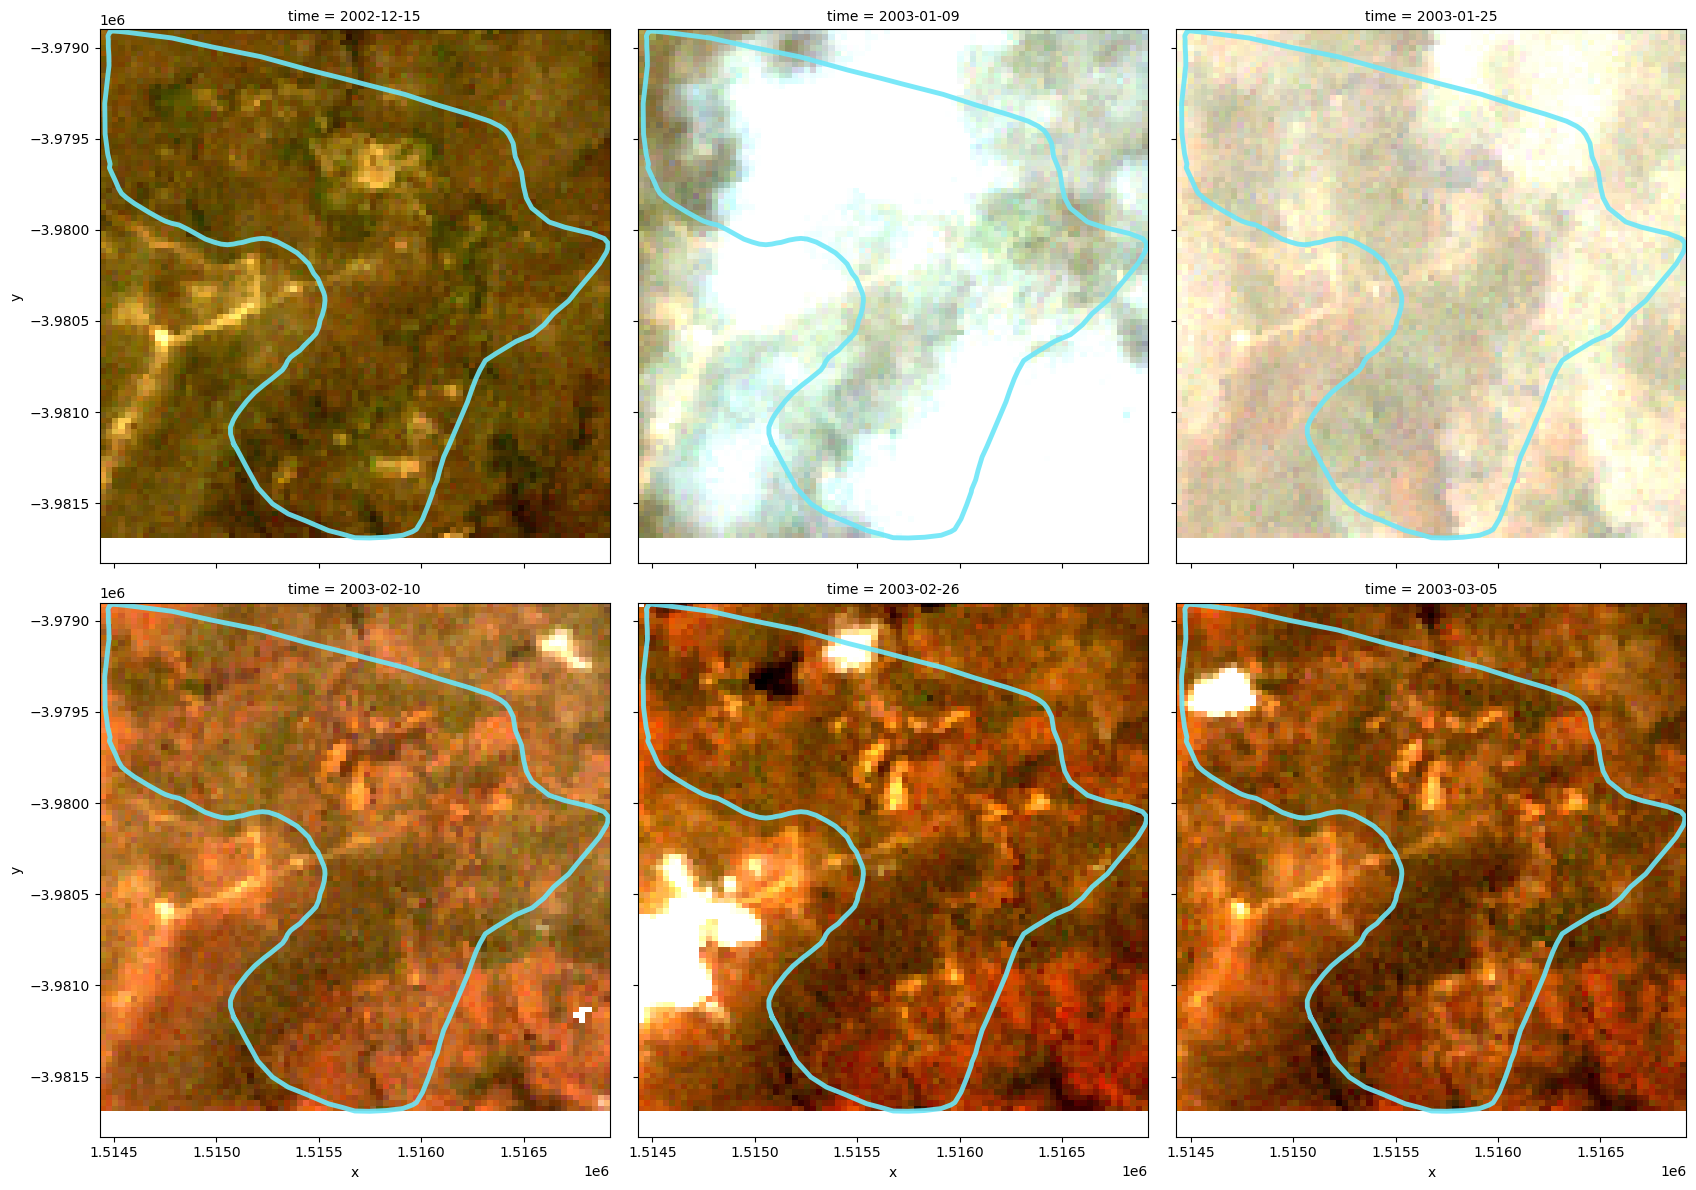

In [25]:
# Create RGB plot
rgb_plot = rgb(ds, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col="time", col_wrap=3, percentile_stretch=[0.10, 0.90]
              )

# Load the shapefile as a GeoDataFrame
poly = gpd.read_file(polygon_path)

# Function to plot polygon on axis
def plot_polygon_on_axis(ax, poly):
    """Overlay polygon outline on the axis."""
    try:
        # Ensure polygon is in the same CRS as the data
        if poly.crs != CRS("EPSG:3577"):
            poly = poly.to_crs("EPSG:3577")
        
        for geom in poly.geometry:
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                ax.plot(x, y, color='#6ce6f8', linewidth=3.5, linestyle='-', alpha=0.9, transform=ax.transData)
            elif geom.geom_type == 'MultiPolygon':
                for poly_part in geom:
                    x, y = poly_part.exterior.xy
                    ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9, transform=ax.transData)
    except Exception as e:
        print(f"Error plotting polygon: {e}")

# Get the current figure (created by rgb())
fig = plt.gcf()

# Plot polygon on all subplot axes
for ax in fig.axes:
    plot_polygon_on_axis(ax, poly)

# Refresh the display
plt.draw()
plt.show()

'Ginini_Flats_animation.gif'

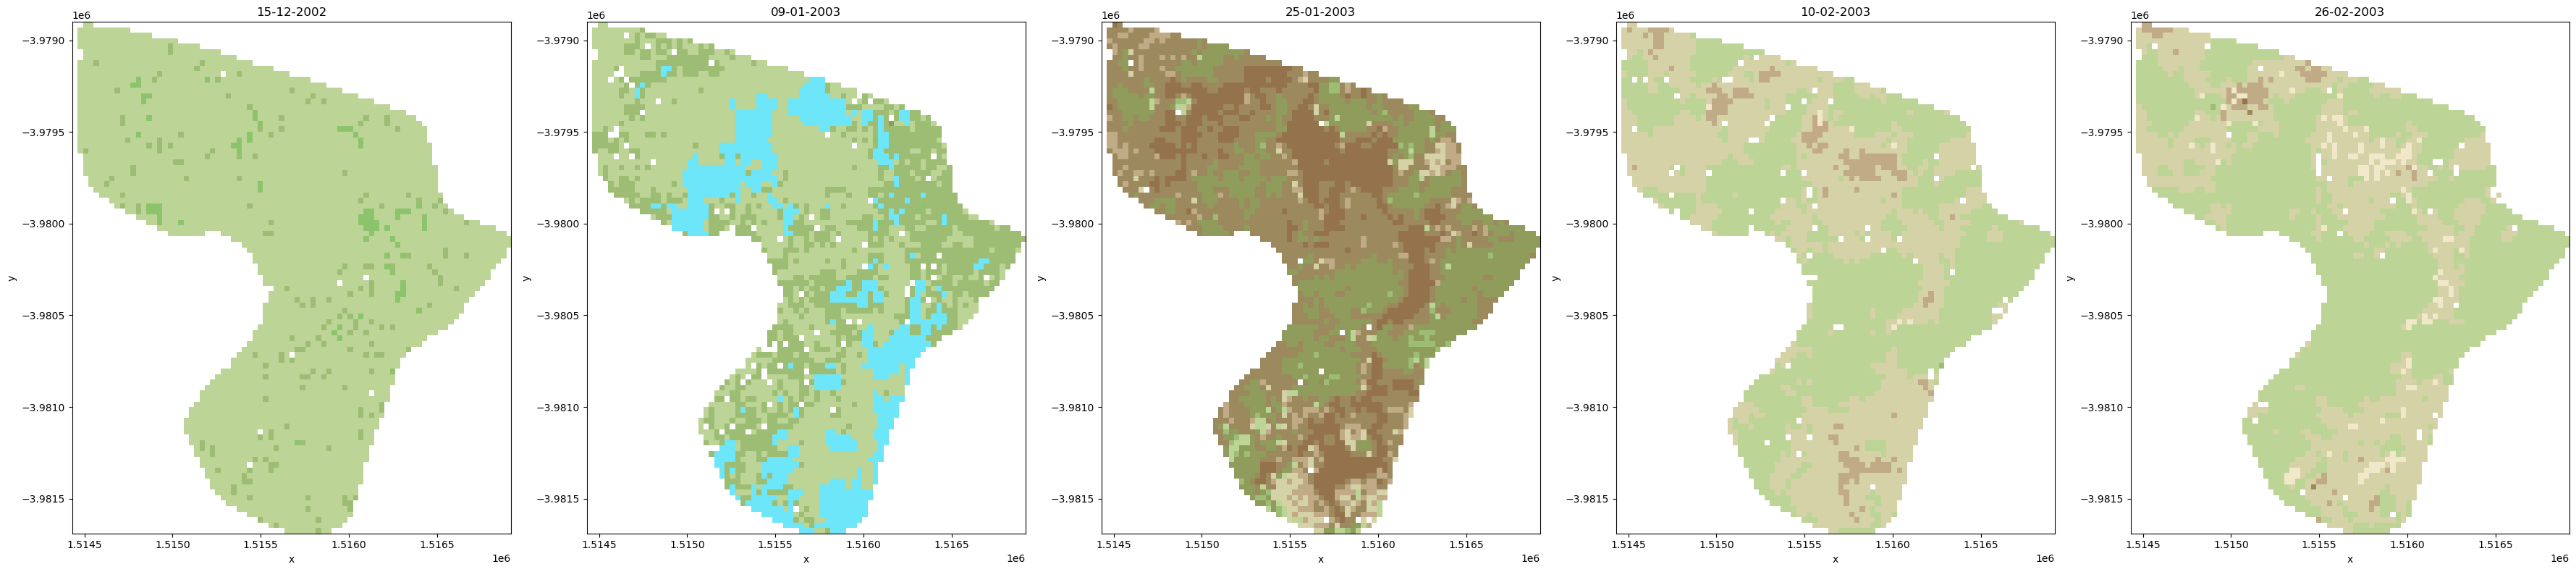

In [26]:
spatial_wit(ds_wit, "Ginini Flats")

The above RGB and Spatial WIT imagery 

<img width="600" height="150" src="../Supplementary_data/WIT_app/Spatial_WIT_cmap.png" alt="Spatial WIT cmap">
<figcaption style="text-align: left;"><b>Figure 2:</b> Ternary diagram depicting fractional cover composition, where each vertex represents a pure end-member: green vegetation, dry vegetation, and bare soil. The plot is subdivided into smaller triangles, representing varying mixtures of these three components, with proportions summing to 100%. </figcaption>
</div>
<br> 

## Flagging data errors with change detection (Test site 2 = Change ID: 7)

Change detection can also highlight errors in the input data that weren’t properly filtered, which can skew results if left unchecked for later analysis. This is shown in the code below. There is a large spike in detected change when stepping through each component with 80–90% minimum good data, but the output is mostly white. This occurs in August 2001, where the 22nd of August produces an error in the change detection plot. Because of the low-quality parameters set for the WIT spatial imagery, the image for 22 August 2001 doesn’t appear at all.

In [27]:
ds_wit, polygon_base_df = WIT_drill(ginini, ("2001-05", "2001-12"))
ds_wit['time'] = ds_wit['time'].dt.floor('D')

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 25 time steps as a dask array
Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2']


In [28]:
# Define which spectral bands are being used in the analysis
bands = [
    f"nbart_{band}" for band in ("blue", "green", "red", "nir", "swir_1", "swir_2")
]

# Load Landsat 5, 7 and 8 data. Not including Landsat 7 SLC off period (31-05-2003 to 06-04-2022).
ds = dea_tools.datahandling.load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    measurements=bands,
    geopolygon=ginini,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    time=("2001-04", "2001-12"),                                           #ACTION: choose before and after month of change ID
    min_gooddata = 0.8,
    dask_chunks={"time": 1, "x": 2048, "y": 2048},
)

# Load into memory using Dask
ds.load()
ds['time'] = ds['time'].dt.floor('D') #make time 0
ds = ds.sel(time=~ds['time'].to_index().duplicated())

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3
    ga_ls5t_ard_3
Counting good quality pixels for each time step using fmask
Filtering to 16 out of 41 time steps with at least 80.0% good quality pixels
Applying fmask pixel quality/cloud mask
Returning 16 time steps as a dask array


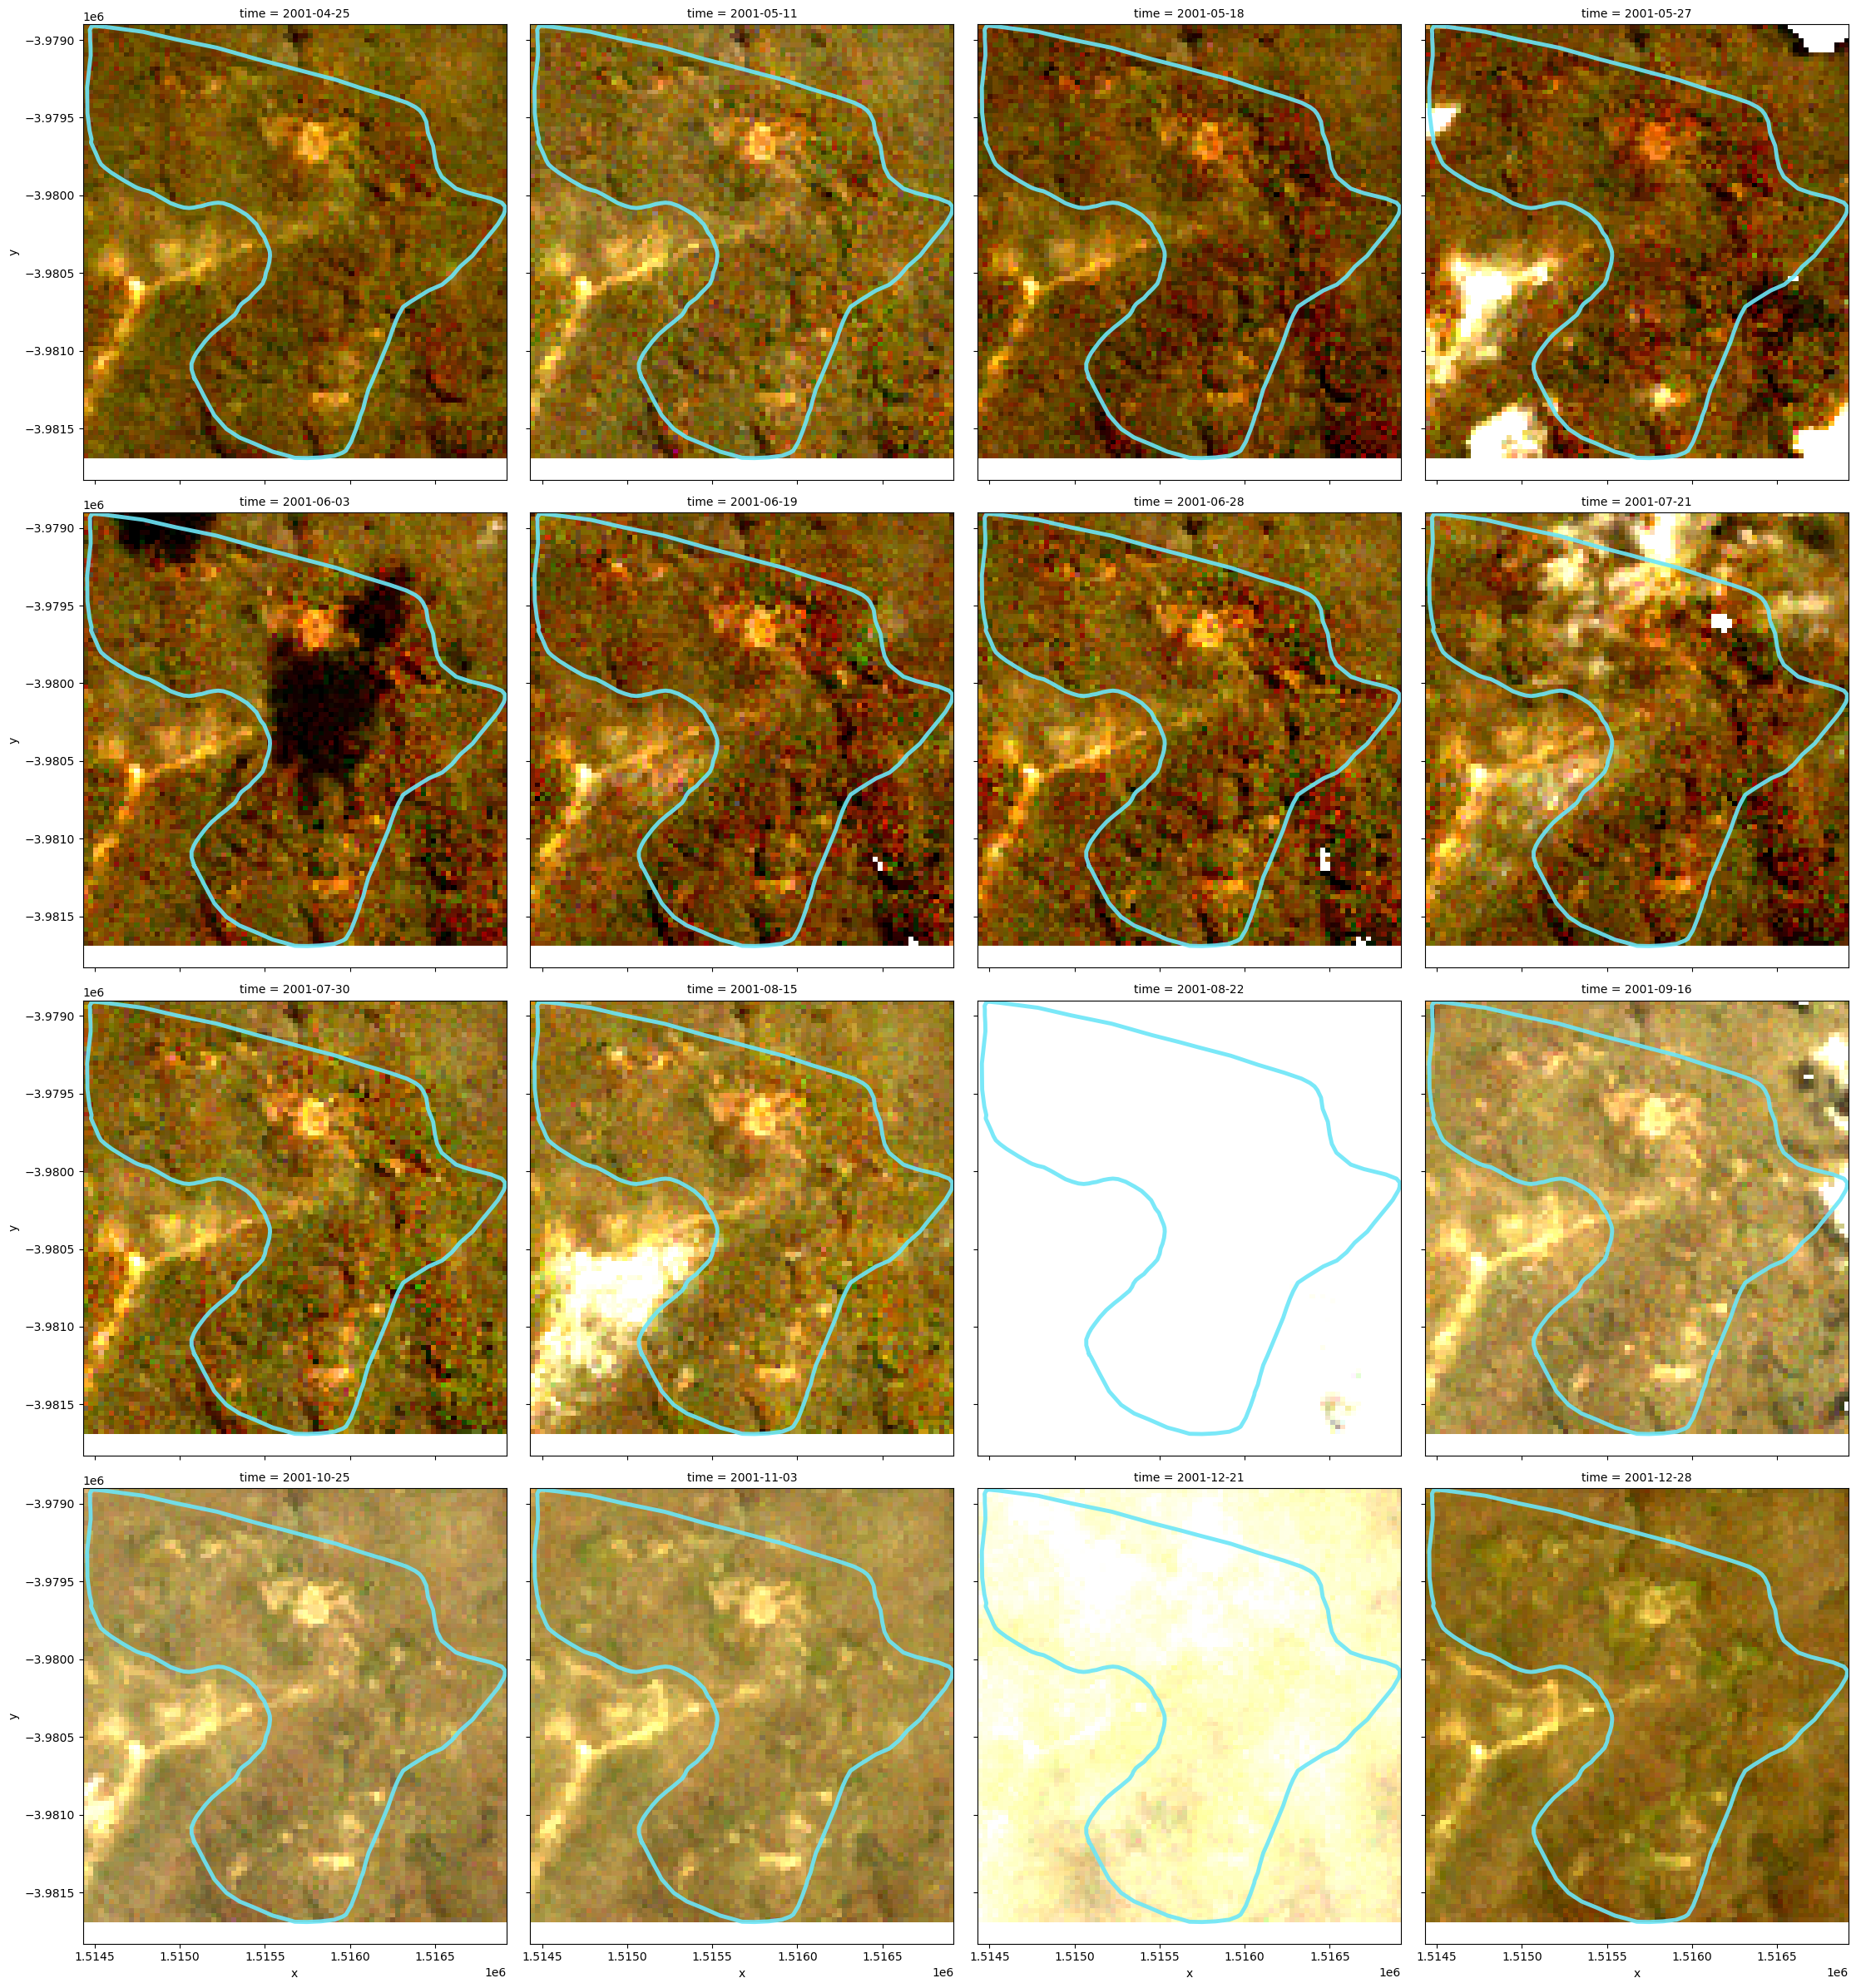

'Ginini_Flats_animation.gif'

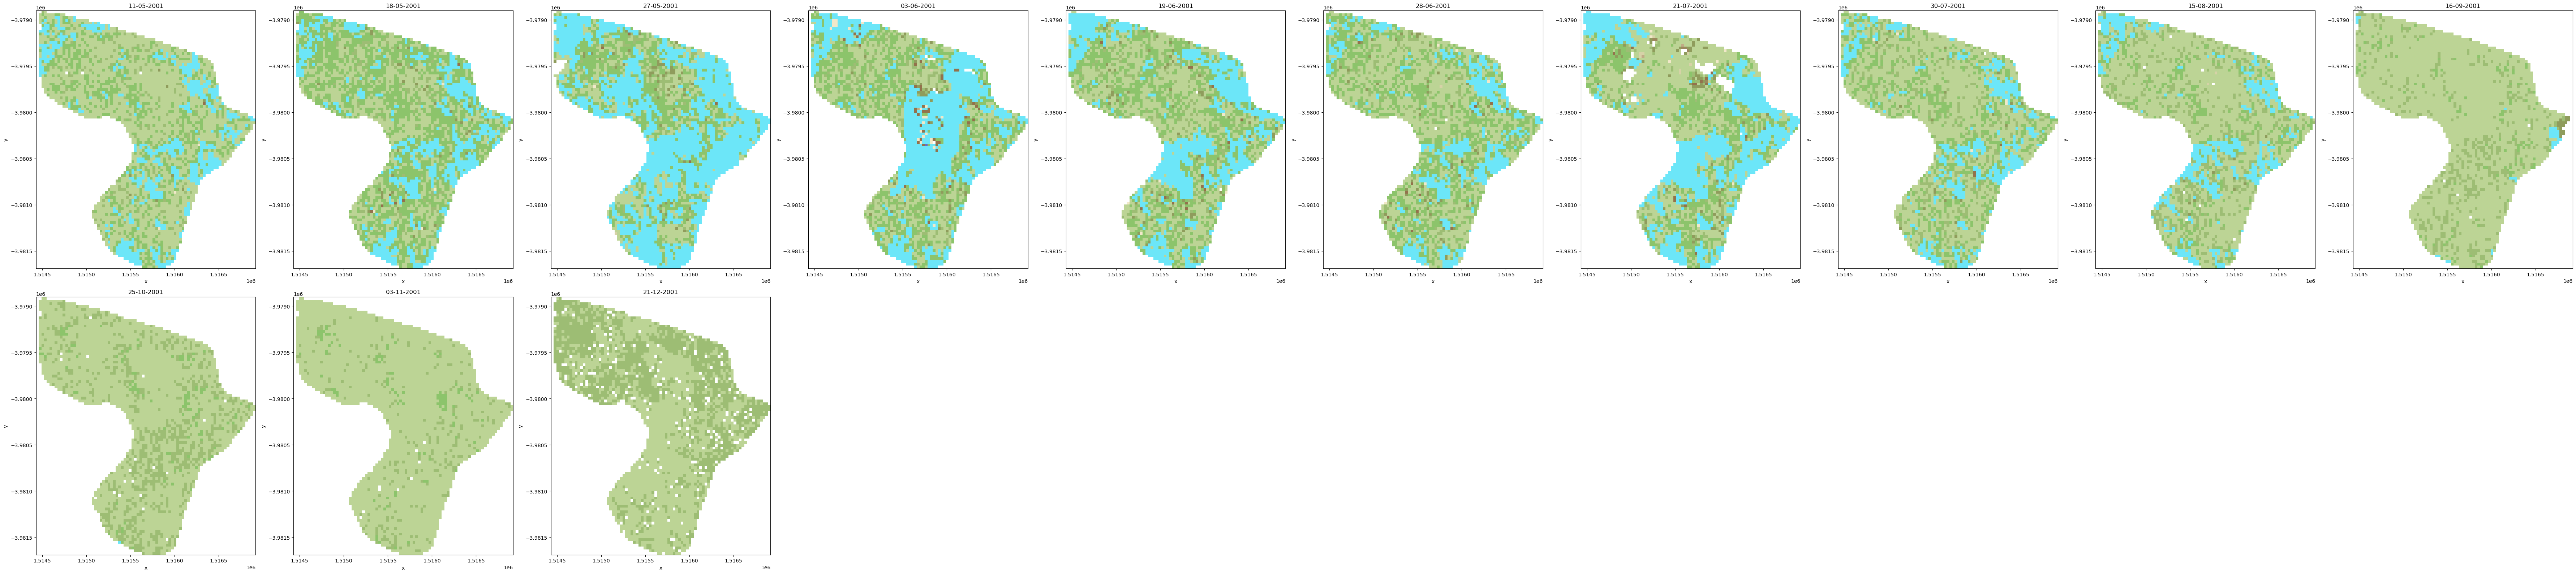

In [29]:
# Create RGB plot
rgb_plot = rgb(ds, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col="time", col_wrap=4, percentile_stretch=[0.10, 0.90]
              )

# Load the shapefile as a GeoDataFrame
poly = gpd.read_file(polygon_path)

# Function to plot polygon on axis
def plot_polygon_on_axis(ax, poly):
    """Overlay polygon outline on the axis."""
    try:
        # Ensure polygon is in the same CRS as the data
        if poly.crs != CRS("EPSG:3577"):
            poly = poly.to_crs("EPSG:3577")
        
        for geom in poly.geometry:
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                ax.plot(x, y, color='#6ce6f8', linewidth=3.5, linestyle='-', alpha=0.9, transform=ax.transData)
            elif geom.geom_type == 'MultiPolygon':
                for poly_part in geom:
                    x, y = poly_part.exterior.xy
                    ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9, transform=ax.transData)
    except Exception as e:
        print(f"Error plotting polygon: {e}")

# Get the current figure (created by rgb())
fig = plt.gcf()

# Plot polygon on all subplot axes
for ax in fig.axes:
    plot_polygon_on_axis(ax, poly)

# Refresh the display
plt.draw()
plt.show()
spatial_wit(ds_wit, "Ginini Flats")

## Snow, cloud, or low data? (Test site 3 = Change ID: 11)

This change ID shows quite a large spike once the usual cyclic patterns start to settle down. This is another timeframe worth investigating, as the imagery could be showing snow cover, cloud filtering, missing data, or a mix of these. Snowfall is an important variable for wetlands because it affects water supply, responds to climate change, and can act as an indicator of how the wetland’s climate is shifting. However, winter imagery is harder to verify, as cloud cover and filtering often reduce the quality and reliability of satellite data during these months.

In [30]:
ds_wit, polygon_base_df = WIT_drill(ginini, ("2018-05", "2018-10"))
ds_wit['time'] = ds_wit['time'].dt.floor('D')

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 23 time steps as a dask array
Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2']


In [31]:
# Define which spectral bands are being used in the analysis
bands = [
    f"nbart_{band}" for band in ("blue", "green", "red", "nir", "swir_1", "swir_2")
]

# Load Landsat 5, 7 and 8 data. Not including Landsat 7 SLC off period (31-05-2003 to 06-04-2022).
ds = dea_tools.datahandling.load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    measurements=bands,
    geopolygon=ginini,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    time=("2018-05", "2018-10"),                                           #ACTION: choose before and after month of change ID
    min_gooddata = 0.8,
    dask_chunks={"time": 1, "x": 2048, "y": 2048},
)

# Load into memory using Dask
ds.load()
ds['time'] = ds['time'].dt.floor('D') #make time 0
ds = ds.sel(time=~ds['time'].to_index().duplicated())

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3
    ga_ls5t_ard_3
Counting good quality pixels for each time step using fmask
Filtering to 11 out of 52 time steps with at least 80.0% good quality pixels
Applying fmask pixel quality/cloud mask
Returning 11 time steps as a dask array


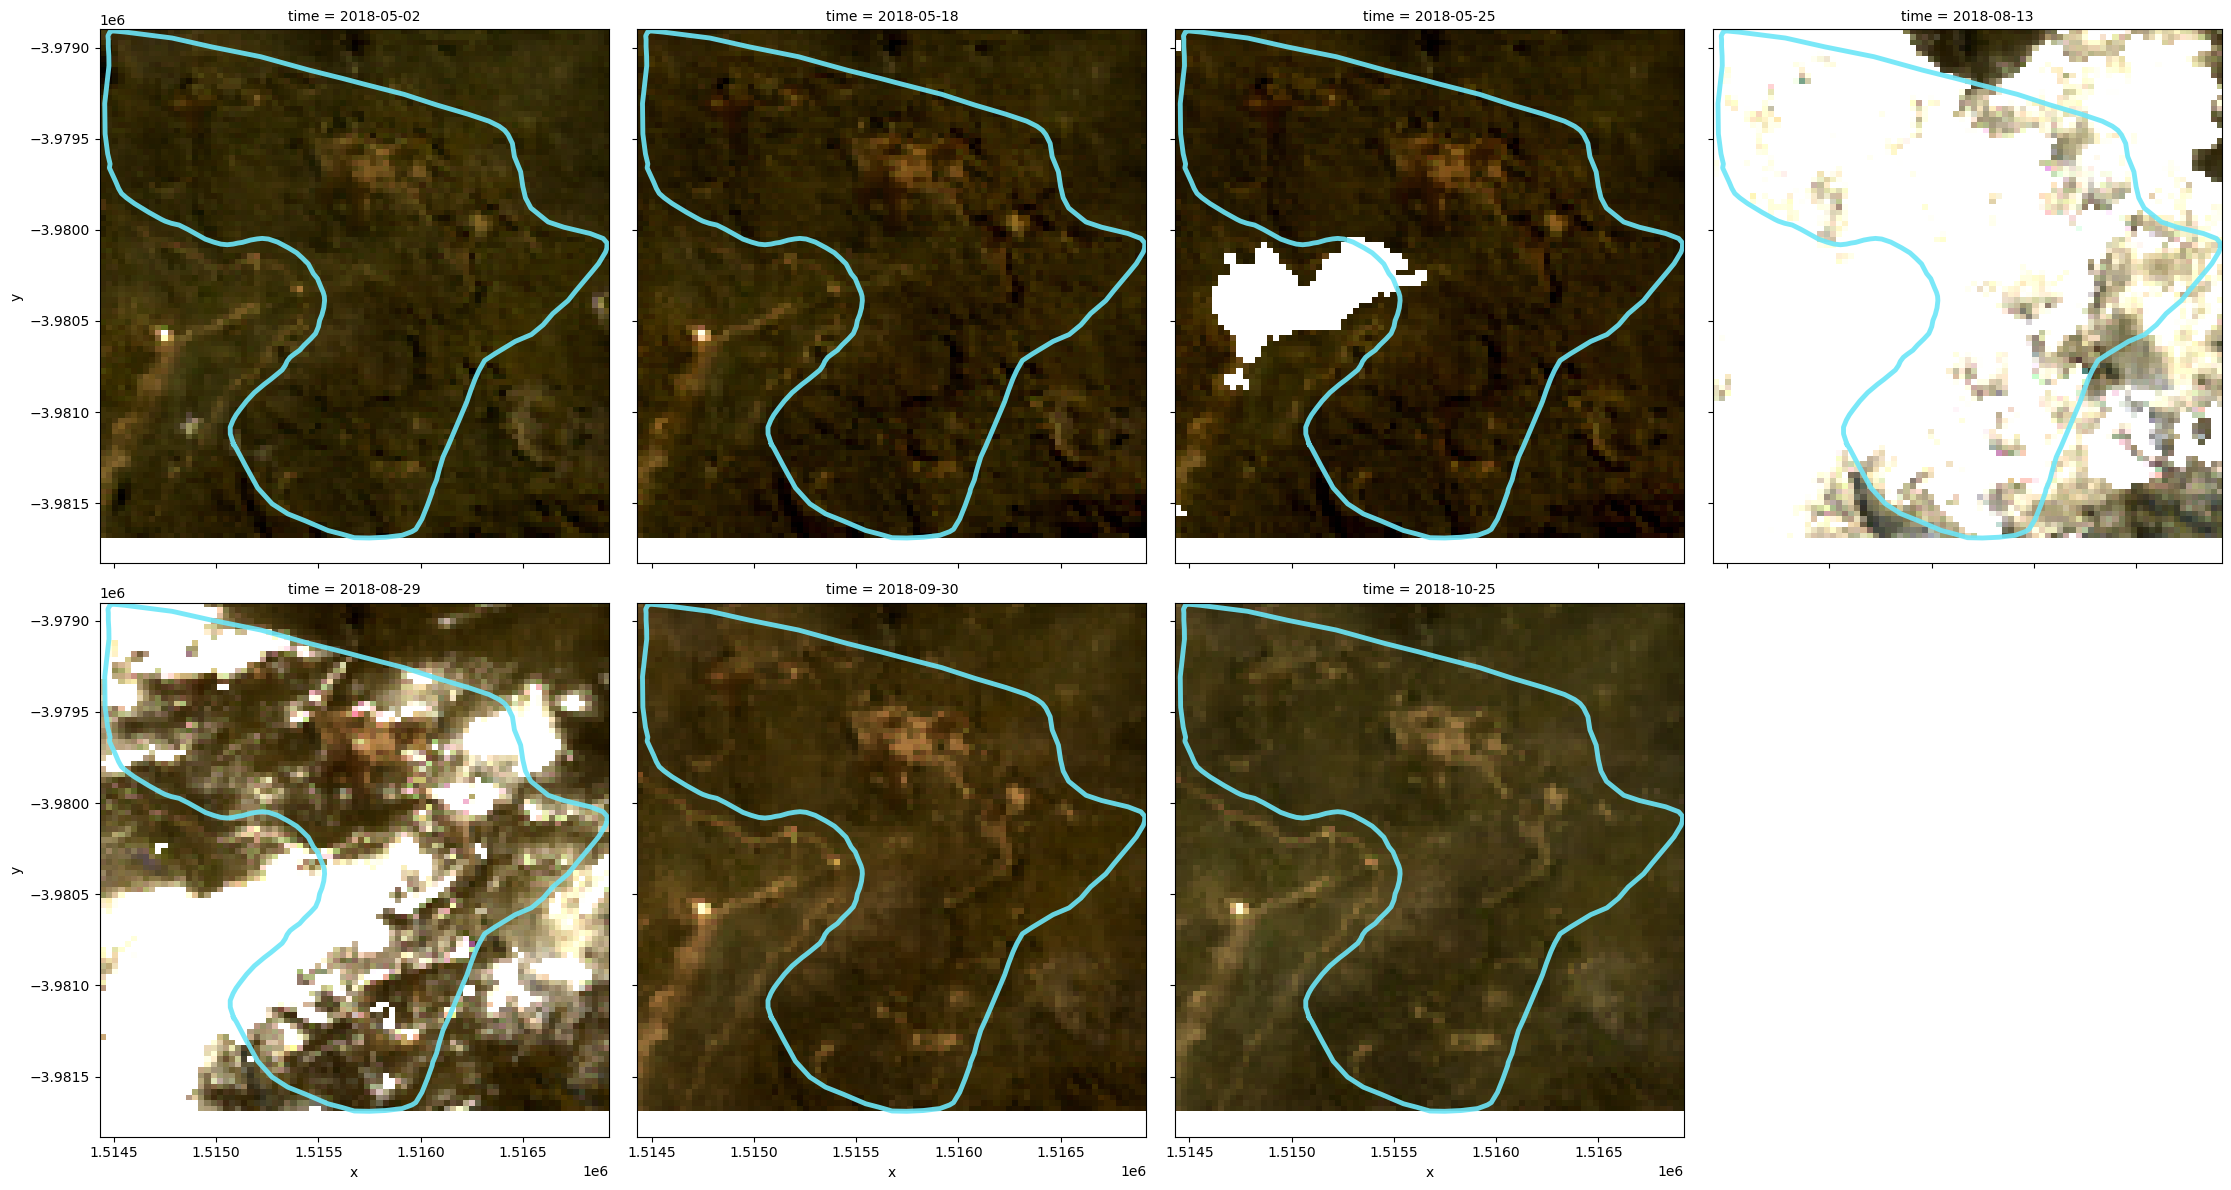

'Ginini_Flats_animation.gif'

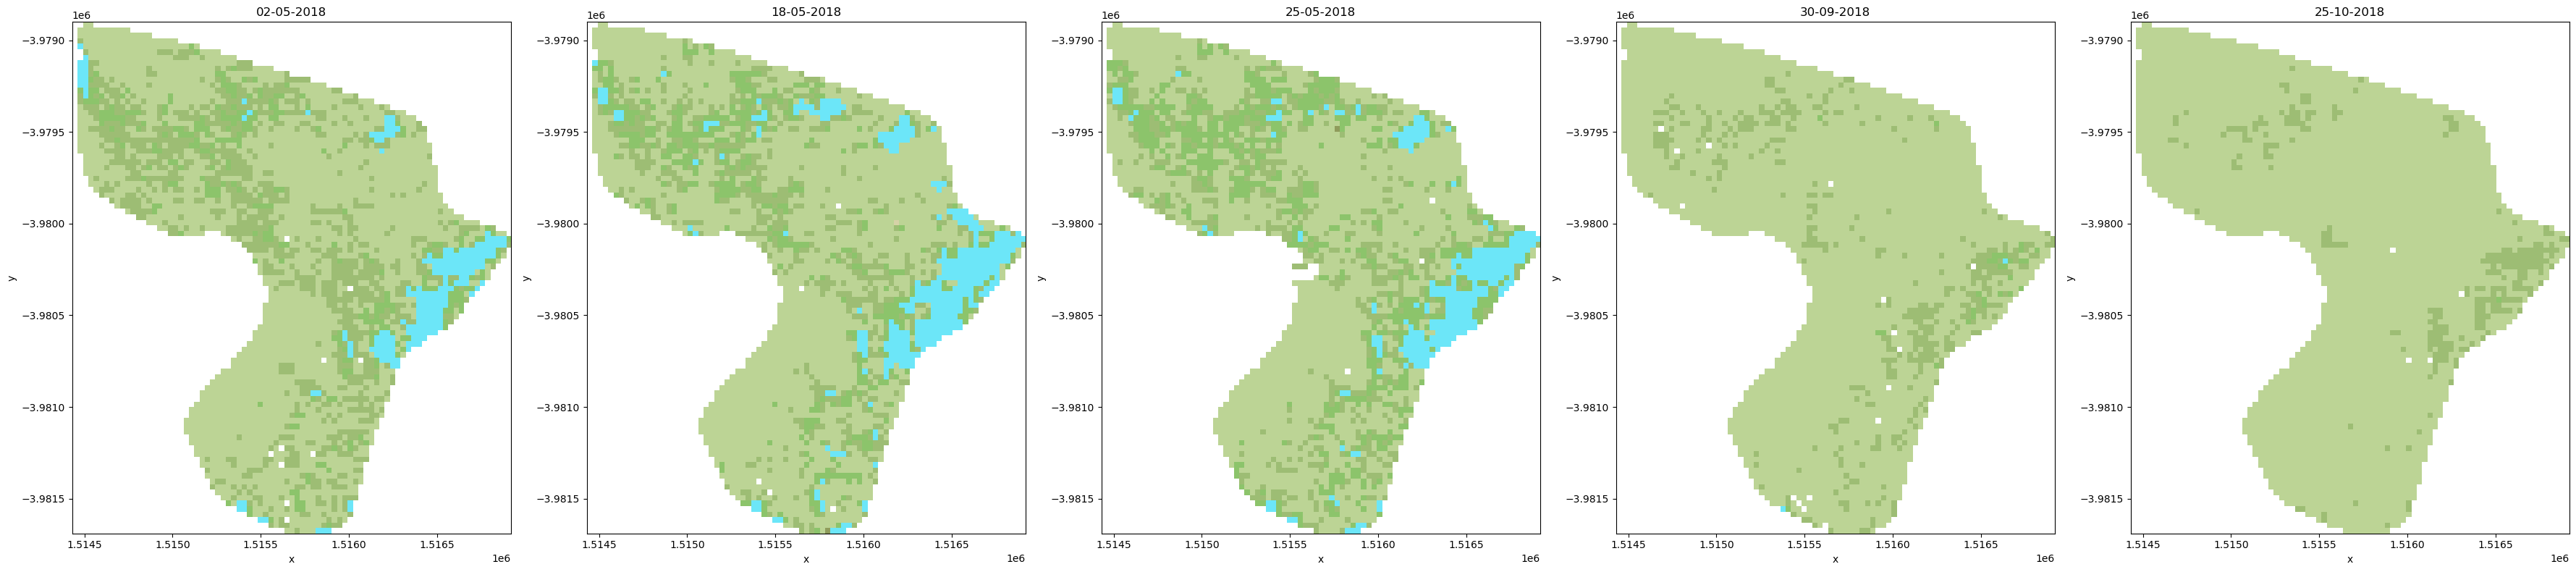

In [32]:
# Create RGB plot
rgb_plot = rgb(ds, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col="time", col_wrap=4, percentile_stretch=[0.10, 0.90]
              )

# Load the shapefile as a GeoDataFrame
poly = gpd.read_file(polygon_path)

# Function to plot polygon on axis
def plot_polygon_on_axis(ax, poly):
    """Overlay polygon outline on the axis."""
    try:
        # Ensure polygon is in the same CRS as the data
        if poly.crs != CRS("EPSG:3577"):
            poly = poly.to_crs("EPSG:3577")
        
        for geom in poly.geometry:
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                ax.plot(x, y, color='#6ce6f8', linewidth=3.5, linestyle='-', alpha=0.9, transform=ax.transData)
            elif geom.geom_type == 'MultiPolygon':
                for poly_part in geom:
                    x, y = poly_part.exterior.xy
                    ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9, transform=ax.transData)
    except Exception as e:
        print(f"Error plotting polygon: {e}")

# Get the current figure (created by rgb())
fig = plt.gcf()

# Plot polygon on all subplot axes
for ax in fig.axes:
    plot_polygon_on_axis(ax, poly)

# Refresh the display
plt.draw()
plt.show()
spatial_wit(ds_wit, "Ginini Flats")

# Conclusion
Change detection is a valuable module within the WIT tool for the Wetland Inventory Project. A thorough analysis requires examining each component separately, but doing so makes the results clearer and more interpretable. The notebook also runs efficiently on the base notebook core environment, making it practical for routine use. It can easily be reproduced for other sites as well. This workflow is useful because it can detect both gradual environmental change across the full timeframe and abrupt shifts caused by events such as bushfires, flooding, or snowfall. In addition to identifying genuine changes in classification, the tool can also flag errors in the data that may slip through the low-quality filtering steps. This is beneficial, as it helps verify how well filtering methods perform across different environments and highlights problematic data that should be excluded from future analysis.


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Citations** &mdash; If you use the DEA Notebooks and Tools repository in your work, please reference
it with the following citation:

> Krause, C., Dunn, B., Bishop-Taylor, R., Adams, C., Burton, C., Alger,
> M., Chua, S., Phillips, C., Newey, V., Kouzoubov, K., Leith, A.,
> Ayers, D., Hicks, A., DEA Notebooks contributors 2021. Digital Earth
> Australia notebooks and tools repository. Geoscience Australia,
> Canberra. <https://doi.org/10.26186/145234>

To cite this notebooks' dataset and research papers in your work you can use the [Publications](#Publications) at the top of this notebook.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** February 2025

**Compatible datacube version:** 

In [25]:
print(datacube.__version__)

1.8.19


## Tags

In [ ]:
**Tags**: :index:`calculate_indices`, :index:`sandbox compatible`, :index:`landsat 5`, :index:`landsat 7`, :index:`landsat 8`, :index:`time series`, :index:`Wetlands_Insight_Tool_(WIT)`, :index:`water observations`, :index:`fractional cover`, :index:`tasseled cap`